## Exception Handling

In [1]:
# Exceptions occur due to invalid operations in python
a = 4
print(a / 0)

ZeroDivisionError: division by zero

In [2]:
b = "Raman"
print(b / 3)

TypeError: unsupported operand type(s) for /: 'str' and 'int'

In [3]:
c = "Two"
d = int(c)

ValueError: invalid literal for int() with base 10: 'Two'

In [4]:
d = 25
print(d / 0)
print("Hello!")

ZeroDivisionError: division by zero

## Exception Handling

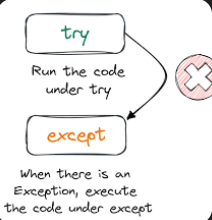

In [5]:
# Without exception handling
def division(num: float | int , den : float | int) -> float:
    return num / den

In [6]:
r1 = division(3, 4)
print(r1)
print("Done")

0.75
Done


In [7]:
r2 = division(12, 0)
print(r2)
print("Done")

ZeroDivisionError: division by zero

In [8]:
r2 = division("Two", 2)
print(r2)
print("Done")

TypeError: unsupported operand type(s) for /: 'str' and 'int'

## With Exception handling
Any error is stored in Exception Class in python

In [9]:
def division2(num: int | float, den: int | float) -> float:
    try:
        return num / den
    except Exception as e:
        print(f"Exception Occured : {e}")

In [10]:
d1 = division2(num=20, den=10)
print(d1)
print("Done")

2.0
Done


In [11]:
d2 = division2(25, 0)
print(d2)
print("Done")

Exception Occured : division by zero
None
Done


In [12]:
d3 = division2("Three", 4)
print(d3)
print("Done")

Exception Occured : unsupported operand type(s) for /: 'str' and 'int'
None
Done


## Custom exception handling
1. ZeroDivisionError
2. TypeError

In [13]:
def division3(num: int | float, den: int | float) -> float:
    try:
        return num / den
    except ZeroDivisionError:
        print("Denominator cannot be 0 in division")
    except TypeError:
        print("Numerator and denominator should be a number")

In [14]:
r1 = division3(100, 20)
print(r1)
print("Done")

5.0
Done


In [15]:
r2 = division3(50, 3)
print(r2)
print("Done")

16.666666666666668
Done


In [16]:
r3 = division3(100, 0)
print(r3)
print("Done")

Denominator cannot be 0 in division
None
Done


In [17]:
r4 = division3("Five", 2)
print(r4)
print("Done")

Numerator and denominator should be a number
None
Done


In [18]:
r5 = division3("a", "b")
print(r5)
print("Done")

Numerator and denominator should be a number
None
Done


## Raise custom errors
I want to take age as input from user

age should be between 0 to 100

In [19]:
def age_validator():
    age = int(input("Please enter age in years : "))
    if age <= 0 or age > 100:
        raise ValueError("Age must be between 1 to 100")
    return age

In [1]:
# Provide age 25
age1 = age_validator()
print(age1)

NameError: name 'age_validator' is not defined

In [2]:
# Negative age : -4
age2 = age_validator()
print(age2)

NameError: name 'age_validator' is not defined

In [3]:
# Age value 200
age3 = age_validator()
print(age3)

NameError: name 'age_validator' is not defined

In [4]:
# With try except block
try:
    age4 = age_validator()
    print(f"Valid age entered : {age4}")
except Exception as e:
    print(f"Exception Occured : {e}")

Exception Occured : name 'age_validator' is not defined


## Different exception handling blocks
1. try -> The code which you will be executing
2. except -> If any error occurs except block will be executed
3. else -> If try block is successful only then else block will be executed
4. finally -> Finally block will always be executed

In [6]:
import math

math.sqrt(25)

5.0

In [7]:
math.sqrt(10)

3.1622776601683795

In [8]:
math.sqrt(-1)

ValueError: expected a nonnegative input, got -1.0

In [9]:
def square_root(num: int | float):
    try:
        s = math.sqrt(num)
    except Exception as e:
        print(f"Exception Occured : {e}")
    else:
        print(f"Square root of {num} is {s}")
        return s
    finally:
        print("Finally block will always be executed")

In [10]:
s1 = square_root(25)

Square root of 25 is 5.0
Finally block will always be executed


In [11]:
s2 = square_root(-10)

Exception Occured : expected a nonnegative input, got -10.0
Finally block will always be executed


In [12]:
s3 = square_root("abc")

Exception Occured : must be real number, not str
Finally block will always be executed


### Download file with exception handling

In [13]:
url = "https://raw.githubusercontent.com/utkarshg1/mlproject_regression/refs/heads/main/artifacts/data.csv"
print(url)

https://raw.githubusercontent.com/utkarshg1/mlproject_regression/refs/heads/main/artifacts/data.csv


In [14]:
url.split("/")

['https:',
 '',
 'raw.githubusercontent.com',
 'utkarshg1',
 'mlproject_regression',
 'refs',
 'heads',
 'main',
 'artifacts',
 'data.csv']

In [15]:
url.split("/")[-1]

'data.csv'

In [16]:
import requests

res = requests.get(url)
res

<Response [200]>

In [17]:
import requests

def download_file(url: str):
    try:
        print("Fetching data")
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        # Save the file using write binary mode 'wb'
        filename = url.split("/")[-1]
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"{filename} downloaded successfully")
    except requests.exceptions.Timeout:
        print("Timeout occured download is taking more than 5 seconds")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP Error : {e}")
    except Exception as e:
        print(f"Unexpected error occured : {e}")
    finally:
        print("Done")

In [18]:
download_file(url)

Fetching data
data.csv downloaded successfully
Done


In [19]:
import pandas as pd
df = pd.read_csv("data.csv")
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [20]:
df.shape

(193573, 11)

In [21]:
download_file("abc")

Fetching data
Unexpected error occured : Invalid URL 'abc': No scheme supplied. Perhaps you meant https://abc?
Done
